In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('project.csv',low_memory=False)


# Convert date column to datetime with day first format
df=data.fillna(0)
df['Date_reported'] = pd.to_datetime(df['Date_reported'], dayfirst=True)
print(df)



Matplotlib is building the font cache; this may take a moment.


       Date_reported Country_code                           Country  \
0         2020-01-04           AI                          Anguilla   
1         2020-01-04           AZ                        Azerbaijan   
2         2020-01-04           BD                        Bangladesh   
3         2020-01-04           BB                          Barbados   
4         2020-01-04           BR                            Brazil   
...              ...          ...                               ...   
457435    2025-03-23           SY              Syrian Arab Republic   
457436    2025-03-23           SB                   Solomon Islands   
457437    2025-03-23           LK                         Sri Lanka   
457438    2025-03-23           VC  Saint Vincent and the Grenadines   
457439    2025-03-23           SN                           Senegal   

       WHO_region  New_cases  Cumulative_cases  New_deaths  Cumulative_deaths  \
0             AMR        0.0                 0         0.0        

In [14]:
print(df.head())

  Date_reported Country_code     Country WHO_region  New_cases  \
0    2020-01-04           AI    Anguilla        AMR        0.0   
1    2020-01-04           AZ  Azerbaijan        EUR        0.0   
2    2020-01-04           BD  Bangladesh       SEAR        0.0   
3    2020-01-04           BB    Barbados        AMR        0.0   
4    2020-01-04           BR      Brazil        AMR        0.0   

   Cumulative_cases  New_deaths  Cumulative_deaths  Unnamed: 8 Unnamed: 9  \
0                 0         0.0                  0         0.0          0   
1                 0         0.0                  0         0.0          0   
2                 0         0.0                  0         0.0          0   
3                 0         0.0                  0         0.0          0   
4                 0         0.0                  0         0.0          0   

   Unnamed: 10  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


In [16]:
print(df.tail())

       Date_reported Country_code                           Country  \
457435    2025-03-23           SY              Syrian Arab Republic   
457436    2025-03-23           SB                   Solomon Islands   
457437    2025-03-23           LK                         Sri Lanka   
457438    2025-03-23           VC  Saint Vincent and the Grenadines   
457439    2025-03-23           SN                           Senegal   

       WHO_region  New_cases  Cumulative_cases  New_deaths  Cumulative_deaths  \
457435        EMR        0.0             57423         0.0               3163   
457436        WPR        0.0             25954         0.0                199   
457437       SEAR        0.0            672812         0.0              16907   
457438        AMR        0.0              9674         0.0                124   
457439        AFR        0.0             89334         0.0               1972   

        Unnamed: 8 Unnamed: 9  Unnamed: 10  
457435         0.0          0          0.

In [2]:
print(df.describe())

                       Date_reported     New_cases  Cumulative_cases  \
count                         457440  4.574400e+05      4.574400e+05   
mean   2022-08-13 12:00:00.000000512  1.700080e+03      1.961042e+06   
min              2020-01-04 00:00:00 -6.507900e+04      0.000000e+00   
25%              2021-04-24 00:00:00  0.000000e+00      5.850750e+03   
50%              2022-08-13 12:00:00  0.000000e+00      5.422100e+04   
75%              2023-12-03 00:00:00  3.900000e+01      6.289430e+05   
max              2025-03-23 00:00:00  6.966046e+06      1.034368e+08   
std                              NaN  3.298219e+04      8.290151e+06   

          New_deaths  Cumulative_deaths  Unnamed: 8  Unnamed: 10  
count  457440.000000       4.574400e+05    457440.0     457440.0  
mean       15.505247       2.112438e+04         0.0          0.0  
min     -3520.000000       0.000000e+00         0.0          0.0  
25%         0.000000       3.600000e+01         0.0          0.0  
50%         0.00

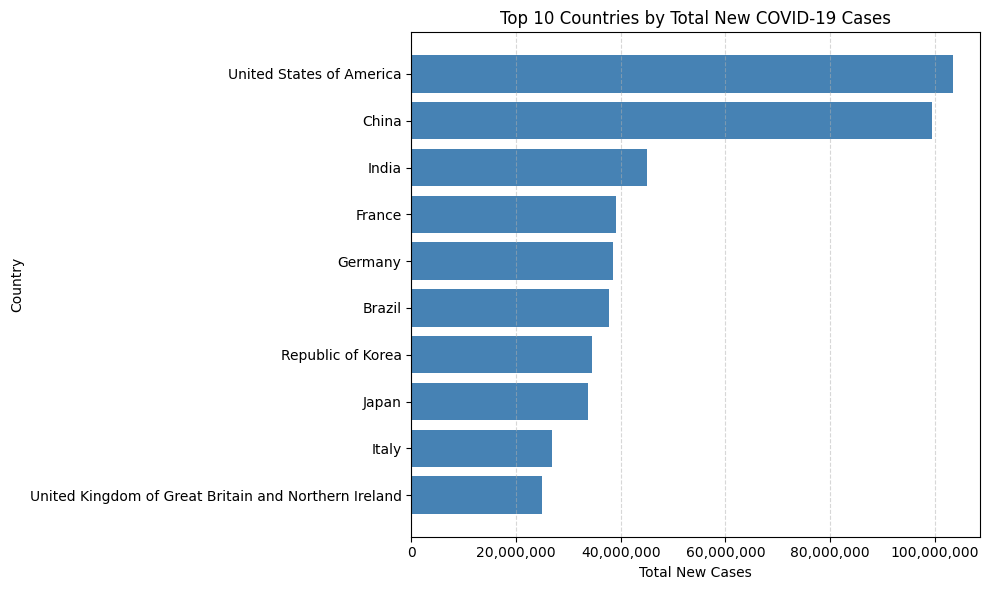

In [3]:

import matplotlib.ticker as ticker

country_cases = df.groupby('Country')['New_cases'].sum().reset_index()
top_10_cases = country_cases.sort_values(by='New_cases', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10_cases['Country'][::-1], top_10_cases['New_cases'][::-1], color='steelblue')
plt.title('Top 10 Countries by Total New COVID-19 Cases')
plt.xlabel('Total New Cases')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()


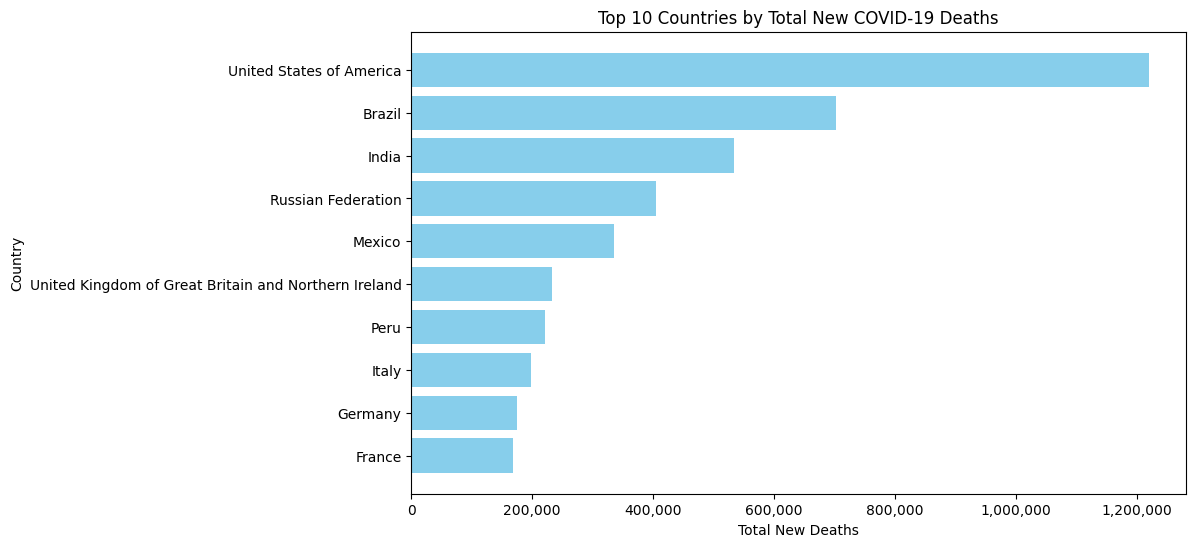

In [4]:
country_deaths = df.groupby('Country')['New_deaths'].sum().reset_index()
top_10_deaths = country_deaths.sort_values(by='New_deaths', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10_deaths['Country'][::-1], top_10_deaths['New_deaths'][::-1], color='skyblue')
plt.title('Top 10 Countries by Total New COVID-19 Deaths')
plt.xlabel('Total New Deaths')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()


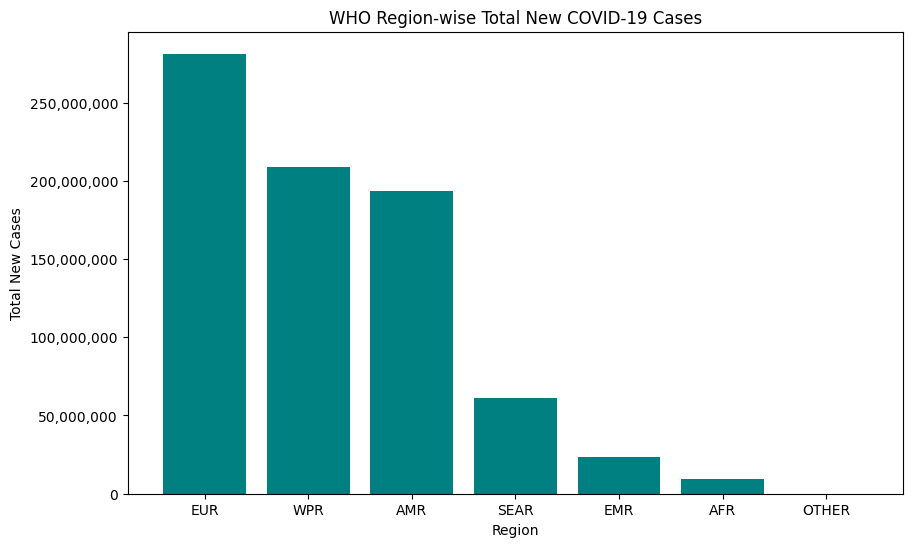

In [30]:
region_cases = df.groupby('WHO_region')['New_cases'].sum().reset_index().sort_values(by='New_cases', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(region_cases['WHO_region'], region_cases['New_cases'], color='teal')
plt.title('WHO Region-wise Total New COVID-19 Cases')
plt.xlabel('Region')
plt.ylabel('Total New Cases')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.show()

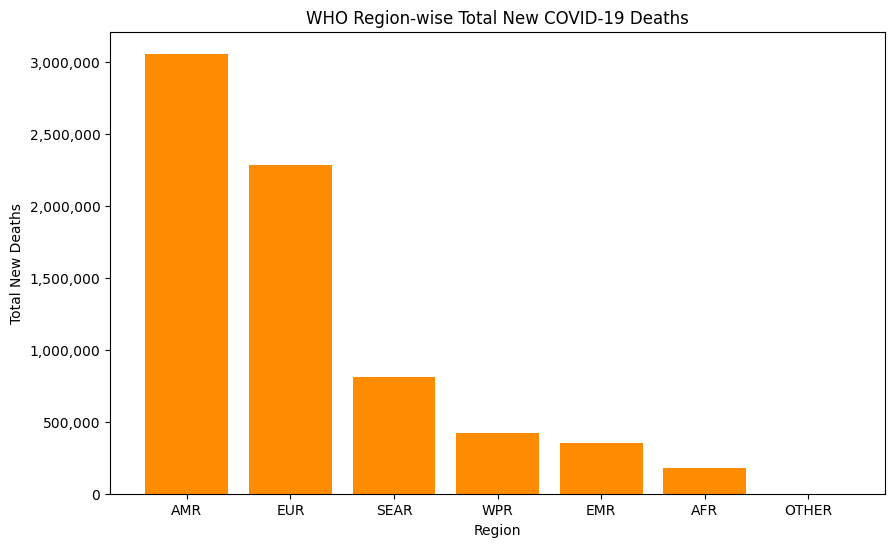

In [34]:
region_deaths = df.groupby('WHO_region')['New_deaths'].sum().reset_index().sort_values(by='New_deaths', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(region_deaths['WHO_region'], region_deaths['New_deaths'], color='darkorange')
plt.title('WHO Region-wise Total New COVID-19 Deaths')
plt.xlabel('Region')
plt.ylabel('Total New Deaths')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
plt.show()

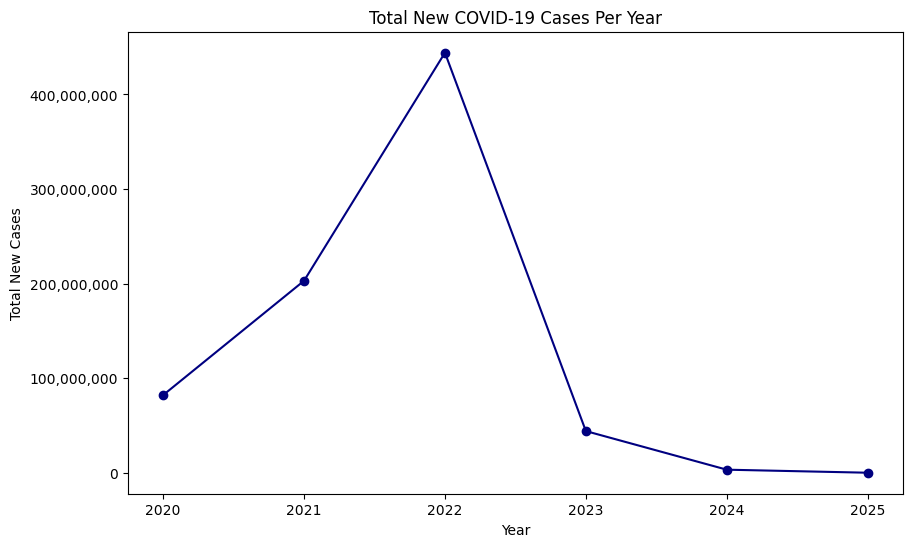

In [37]:
df['Year'] = df['Date_reported'].dt.year
yearly_cases = df.groupby('Year')['New_cases'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(yearly_cases['Year'], yearly_cases['New_cases'], marker='o', linestyle='-', color='navy')
plt.title('Total New COVID-19 Cases Per Year')
plt.xlabel('Year')
plt.ylabel('Total New Cases')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.show()

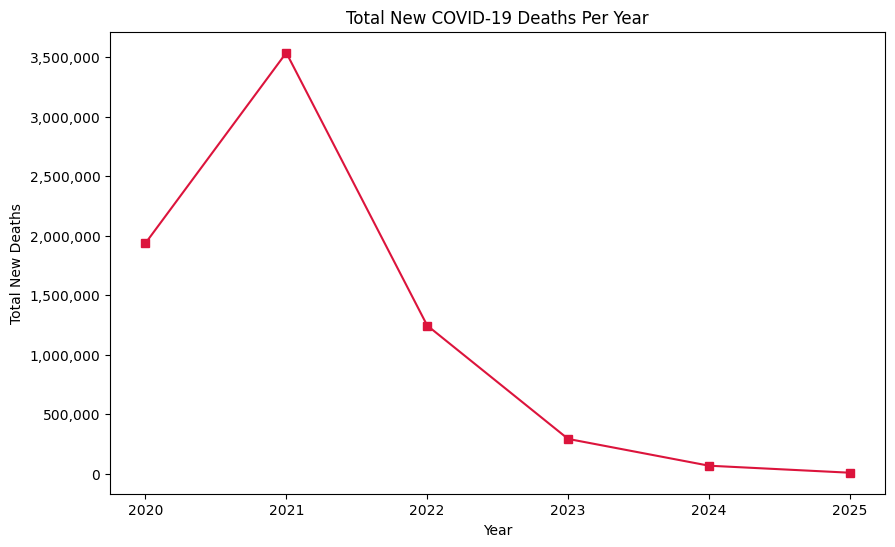

In [38]:
yearly_deaths = df.groupby('Year')['New_deaths'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(yearly_deaths['Year'], yearly_deaths['New_deaths'], marker='s', linestyle='-', color='crimson')
plt.title('Total New COVID-19 Deaths Per Year')
plt.xlabel('Year')
plt.ylabel('Total New Deaths')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.show()